# 🎵 Music Plagiarism Detection - Optimized Baseline
## ML Week Hackathon (IT-Jim)

**Оптимізована версія з:**
- ✅ librosa DTW (швидкий)
- ✅ Subsequence DTW (для часткового плагіату)
- ✅ HPCP features (краще за chroma)
- ✅ MFCC (тембр)
- ✅ Beat synchronization
- ✅ OTI (транспозиція тональності)

In [1]:
# Встановлення
!pip install librosa pandas matplotlib -q
print("✅ Installed!")

✅ Installed!


In [2]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports ready!")

✅ Imports ready!


In [ ]:
# Google Colab - mount drive
# from google.colab import drive
# drive.mount('/content/drive')

## 📁 Configuration

In [3]:
@dataclass
class Config:
    """Конфігурація пайплайну"""
    sr: int = 22050
    hop_length: int = 512
    
    # Features
    use_beat_sync: bool = True
    use_oti: bool = True
    use_mfcc: bool = True
    
    # Weights
    weight_dtw: float = 0.35
    weight_subseq: float = 0.25
    weight_cosine: float = 0.20
    weight_mfcc: float = 0.20
    
    # Threshold
    threshold: float = 0.55

config = Config()
print(f"Config: threshold={config.threshold}, beat_sync={config.use_beat_sync}")

Config: threshold=0.55, beat_sync=True


In [4]:
# === PATHS ===
DATA_DIR = Path('/Users/ulanagusar/Desktop/ML_week-2026/smp_dataset')  # ЗМІНІТЬ!

ORIGINAL_FOLDER = DATA_DIR / 'original'
COMPARISON_FOLDER = DATA_DIR / 'comparison'
CSV_PATH = DATA_DIR / 'song_pairs_balanced.csv'

print(f"Original: {ORIGINAL_FOLDER.exists()}")
print(f"Comparison: {COMPARISON_FOLDER.exists()}")
print(f"CSV: {CSV_PATH.exists()}")

Original: True
Comparison: True
CSV: True


## 🔧 Core Functions

In [5]:
# ============= FEATURE EXTRACTION =============

def load_audio(path: str, sr: int = 22050) -> np.ndarray:
    """Load and normalize audio"""
    y, _ = librosa.load(path, sr=sr, mono=True)
    return librosa.util.normalize(y)


def extract_hpcp(y: np.ndarray, sr: int = 22050, hop_length: int = 512) -> np.ndarray:
    """
    HPCP-like features using Chroma CENS.
    Більш робастний за звичайний chroma.
    """
    return librosa.feature.chroma_cens(y=y, sr=sr, hop_length=hop_length)


def extract_mfcc(y: np.ndarray, sr: int = 22050, n_mfcc: int = 13) -> np.ndarray:
    """MFCC features for timbre"""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # Normalize
    return (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / (np.std(mfcc, axis=1, keepdims=True) + 1e-8)


def beat_sync(features: np.ndarray, y: np.ndarray, sr: int = 22050) -> np.ndarray:
    """Sync features to beats"""
    tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
    if len(beats) > 1:
        return librosa.util.sync(features, beats, aggregate=np.median)
    return features


def extract_features(path: str, cfg: Config) -> Dict[str, np.ndarray]:
    """Extract all features from audio file"""
    y = load_audio(path, cfg.sr)
    
    # HPCP
    hpcp = extract_hpcp(y, cfg.sr, cfg.hop_length)
    if cfg.use_beat_sync:
        hpcp = beat_sync(hpcp, y, cfg.sr)
    
    features = {'hpcp': hpcp, 'y': y}
    
    # MFCC
    if cfg.use_mfcc:
        mfcc = extract_mfcc(y, cfg.sr)
        if cfg.use_beat_sync:
            mfcc = beat_sync(mfcc, y, cfg.sr)
        features['mfcc'] = mfcc
    
    return features

print("✅ Feature extraction ready!")

✅ Feature extraction ready!


In [6]:
# ============= OTI =============

def compute_oti(hpcp1: np.ndarray, hpcp2: np.ndarray) -> int:
    """
    Optimal Transposition Index.
    Знаходить найкращий зсув тональності (0-11).
    """
    gc1 = np.mean(hpcp1, axis=1)
    gc2 = np.mean(hpcp2, axis=1)
    
    gc1 = gc1 / (np.linalg.norm(gc1) + 1e-8)
    gc2 = gc2 / (np.linalg.norm(gc2) + 1e-8)
    
    # Cross-correlation via FFT
    corr = np.real(np.fft.ifft(np.fft.fft(gc1) * np.conj(np.fft.fft(gc2))))
    return int(np.argmax(corr))


def apply_oti(hpcp: np.ndarray, oti: int) -> np.ndarray:
    """Apply OTI shift"""
    return np.roll(hpcp, oti, axis=0) if oti != 0 else hpcp

print("✅ OTI ready!")

✅ OTI ready!


In [7]:
# ============= SIMILARITY METRICS =============

def dtw_similarity(feat1: np.ndarray, feat2: np.ndarray, metric: str = 'cosine') -> float:
    """
    DTW similarity using librosa.
    Returns: similarity (0-1)
    """
    D, _ = librosa.sequence.dtw(feat1, feat2, metric=metric)
    n, m = D.shape
    distance = D[-1, -1] / (n + m)
    return float(max(0, 1 - distance))


def subsequence_dtw_similarity(query: np.ndarray, reference: np.ndarray) -> Tuple[float, int, int]:
    """
    Subsequence DTW - finds best match of query within reference.
    Ідеально коли плагіат - лише частина пісні.
    """
    try:
        D, wp = librosa.sequence.dtw(query, reference, metric='cosine', subseq=True)
        
        end_idx = int(np.argmin(D[-1, :]))
        min_cost = D[-1, end_idx]
        distance = min_cost / query.shape[1]
        similarity = float(max(0, 1 - distance))
        
        start_idx = max(0, end_idx - query.shape[1])
        return similarity, start_idx, end_idx
    except:
        return 0.0, 0, 0


def cosine_similarity(feat1: np.ndarray, feat2: np.ndarray) -> float:
    """Global cosine similarity"""
    g1 = np.mean(feat1, axis=1)
    g2 = np.mean(feat2, axis=1)
    sim = np.dot(g1, g2) / (np.linalg.norm(g1) * np.linalg.norm(g2) + 1e-8)
    return float(max(0, sim))


def mfcc_similarity(mfcc1: np.ndarray, mfcc2: np.ndarray) -> float:
    """MFCC similarity using DTW"""
    try:
        D, _ = librosa.sequence.dtw(mfcc1, mfcc2, metric='euclidean')
        distance = D[-1, -1] / (D.shape[0] + D.shape[1])
        return float(max(0, 1 - distance / 10))
    except:
        return 0.0

print("✅ Similarity metrics ready!")

✅ Similarity metrics ready!


In [8]:
# ============= MAIN COMPARISON =============

@dataclass
class ComparisonResult:
    """Result of comparing two tracks"""
    combined_score: float
    is_plagiarism: bool
    dtw_sim: float
    subseq_sim: float
    cosine_sim: float
    mfcc_sim: float
    oti: int


def compare_tracks(path1: str, path2: str, cfg: Config) -> ComparisonResult:
    """
    Compare two audio files.
    
    Args:
        path1: Query (potential plagiarism)
        path2: Reference (original)
        cfg: Configuration
    
    Returns:
        ComparisonResult
    """
    # 1. Extract features
    feat1 = extract_features(path1, cfg)
    feat2 = extract_features(path2, cfg)
    
    # 2. OTI alignment
    oti = compute_oti(feat1['hpcp'], feat2['hpcp']) if cfg.use_oti else 0
    hpcp2_aligned = apply_oti(feat2['hpcp'], oti)
    
    # 3. Calculate similarities
    dtw_sim = dtw_similarity(feat1['hpcp'], hpcp2_aligned)
    subseq_sim, _, _ = subsequence_dtw_similarity(feat1['hpcp'], hpcp2_aligned)
    cos_sim = cosine_similarity(feat1['hpcp'], hpcp2_aligned)
    
    mfcc_sim = 0.0
    if cfg.use_mfcc and 'mfcc' in feat1 and 'mfcc' in feat2:
        mfcc_sim = mfcc_similarity(feat1['mfcc'], feat2['mfcc'])
    
    # 4. Combine scores
    combined = (
        cfg.weight_dtw * dtw_sim +
        cfg.weight_subseq * subseq_sim +
        cfg.weight_cosine * cos_sim +
        cfg.weight_mfcc * mfcc_sim
    )
    
    # Boost if subsequence found good match
    if subseq_sim > dtw_sim + 0.1:
        combined = max(combined, subseq_sim * 0.9)
    
    # 5. Decision
    is_plagiarism = combined > cfg.threshold
    
    return ComparisonResult(
        combined_score=combined,
        is_plagiarism=is_plagiarism,
        dtw_sim=dtw_sim,
        subseq_sim=subseq_sim,
        cosine_sim=cos_sim,
        mfcc_sim=mfcc_sim,
        oti=oti
    )

print("✅ Comparison function ready!")

✅ Comparison function ready!


## 🧪 Test on Single Pair

In [9]:
# Load dataset
df = pd.read_csv(CSV_PATH)
df['label'] = df['relation'].apply(lambda x: 0 if x == 'not_plag' else 1)

print(f"Total pairs: {len(df)}")
print(df['relation'].value_counts())

Total pairs: 32
relation
not_plag      16
plag           6
remake         5
plag_doubt     5
Name: count, dtype: int64


In [10]:
# File finder
import re

def find_file(folder: Path, title: str) -> Optional[Path]:
    """Find audio file by title"""
    title_simple = re.sub(r'[^a-z0-9]', '', title.lower())
    
    for f in folder.glob('*'):
        if f.is_file():
            fname_simple = re.sub(r'[^a-z0-9]', '', f.stem.lower())
            if fname_simple == title_simple:
                return f
            if len(title_simple) > 10 and title_simple[:25] in fname_simple:
                return f
            if len(fname_simple) > 10 and fname_simple[:25] in title_simple:
                return f
    return None

In [11]:
# Test on one pair
idx = 4  # Queen vs Vanilla Ice
row = df.iloc[idx]

print(f"Original: {row['ori_title'][:50]}")
print(f"Comparison: {row['comp_title'][:50]}")
print(f"Relation: {row['relation']}")

ori_path = find_file(ORIGINAL_FOLDER, row['ori_title'])
comp_path = find_file(COMPARISON_FOLDER, row['comp_title'])

if ori_path and comp_path:
    result = compare_tracks(str(comp_path), str(ori_path), config)
    
    print("\n" + "="*50)
    status = "🚨 PLAGIARISM" if result.is_plagiarism else "✅ NOT PLAGIARISM"
    print(status)
    print(f"\nCombined Score: {result.combined_score:.3f}")
    print(f"\nBreakdown:")
    print(f"  DTW:        {result.dtw_sim:.3f}")
    print(f"  Subsequence: {result.subseq_sim:.3f}")
    print(f"  Cosine:     {result.cosine_sim:.3f}")
    print(f"  MFCC:       {result.mfcc_sim:.3f}")
    print(f"  OTI:        {result.oti} semitones")
else:
    print("Files not found!")

Original: Queen - Under Pressure _Official Video_
Comparison: Vanilla Ice - Ice Ice Baby _Official Music Video_
Relation: plag

🚨 PLAGIARISM

Combined Score: 0.876

Breakdown:
  DTW:        0.887
  Subsequence: 0.926
  Cosine:     0.890
  MFCC:       0.778
  OTI:        1 semitones


## 📊 Full Dataset Evaluation

In [12]:
def evaluate_dataset(df, original_folder, comparison_folder, cfg, verbose=True):
    """Evaluate on full dataset"""
    results = []
    
    for idx, row in df.iterrows():
        true_label = 0 if row['relation'] == 'not_plag' else 1
        
        ori_path = find_file(original_folder, row['ori_title'])
        comp_path = find_file(comparison_folder, row['comp_title'])
        
        if not ori_path or not comp_path:
            if verbose:
                print(f"[{idx:2d}] ⚠️ Files not found")
            results.append({'idx': idx, 'true': true_label, 'pred': None, 'score': None, 'status': 'NOT_FOUND'})
            continue
        
        try:
            res = compare_tracks(str(comp_path), str(ori_path), cfg)
            pred = 1 if res.is_plagiarism else 0
            
            correct = "✓" if pred == true_label else "✗"
            if verbose:
                print(f"[{idx:2d}] {correct} Score: {res.combined_score:.3f} | "
                      f"DTW: {res.dtw_sim:.2f} | Sub: {res.subseq_sim:.2f} | "
                      f"OTI: {res.oti:2d} | {row['relation']}")
            
            results.append({
                'idx': idx, 'true': true_label, 'pred': pred,
                'score': res.combined_score,
                'dtw': res.dtw_sim, 'subseq': res.subseq_sim,
                'cosine': res.cosine_sim, 'mfcc': res.mfcc_sim,
                'oti': res.oti, 'relation': row['relation'], 'status': 'OK'
            })
        except Exception as e:
            if verbose:
                print(f"[{idx:2d}] ❌ Error: {e}")
            results.append({'idx': idx, 'true': true_label, 'pred': None, 'score': None, 'status': 'ERROR'})
    
    return pd.DataFrame(results)

In [13]:
# Run evaluation
print("="*60)
print("EVALUATION")
print("="*60)

results_df = evaluate_dataset(df, ORIGINAL_FOLDER, COMPARISON_FOLDER, config)

EVALUATION
[ 0] ✓ Score: 0.941 | DTW: 0.96 | Sub: 0.98 | OTI:  3 | plag
[ 1] ✓ Score: 0.895 | DTW: 0.93 | Sub: 0.86 | OTI: 11 | remake
[ 2] ✓ Score: 0.881 | DTW: 0.91 | Sub: 0.83 | OTI:  0 | remake
[ 3] ✓ Score: 0.907 | DTW: 0.91 | Sub: 0.92 | OTI:  5 | plag
[ 4] ✓ Score: 0.876 | DTW: 0.89 | Sub: 0.93 | OTI:  1 | plag
[ 5] ✓ Score: 0.886 | DTW: 0.89 | Sub: 0.90 | OTI:  1 | plag
[ 6] ✓ Score: 0.907 | DTW: 0.91 | Sub: 0.92 | OTI:  6 | plag_doubt
[ 7] ✓ Score: 0.923 | DTW: 0.93 | Sub: 0.93 | OTI:  3 | plag_doubt
[ 8] ✓ Score: 0.875 | DTW: 0.88 | Sub: 0.84 | OTI:  0 | remake
[ 9] ✓ Score: 0.891 | DTW: 0.87 | Sub: 0.94 | OTI:  3 | plag_doubt
[10] ✓ Score: 0.908 | DTW: 0.93 | Sub: 0.90 | OTI:  9 | plag_doubt
[11] ✓ Score: 0.856 | DTW: 0.89 | Sub: 0.80 | OTI:  0 | plag_doubt
[12] ✓ Score: 0.939 | DTW: 0.96 | Sub: 0.97 | OTI:  6 | remake
[13] ✓ Score: 0.852 | DTW: 0.85 | Sub: 0.84 | OTI:  5 | remake
[14] ✓ Score: 0.915 | DTW: 0.91 | Sub: 0.94 | OTI:  1 | plag
[15] ✓ Score: 0.928 | DTW: 0.95 | 

In [14]:
def print_metrics(results_df):
    """Print evaluation metrics"""
    valid = results_df[results_df['status'] == 'OK']
    
    if len(valid) == 0:
        print("No valid results!")
        return
    
    y_true = valid['true'].values
    y_pred = valid['pred'].values
    
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print("\n" + "="*50)
    print("📊 RESULTS")
    print("="*50)
    print(f"Valid: {len(valid)}/{len(results_df)}")
    print("-"*50)
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print("-"*50)
    print(f"Confusion Matrix:")
    print(f"            Pred 0  Pred 1")
    print(f"True 0       {tn:3d}     {fp:3d}")
    print(f"True 1       {fn:3d}     {tp:3d}")
    print("="*50)

print_metrics(results_df)


📊 RESULTS
Valid: 32/32
--------------------------------------------------
Accuracy:  0.500
Precision: 0.500
Recall:    1.000
F1 Score:  0.667
--------------------------------------------------
Confusion Matrix:
            Pred 0  Pred 1
True 0         0      16
True 1         0      16


## 📈 Analysis & Visualization

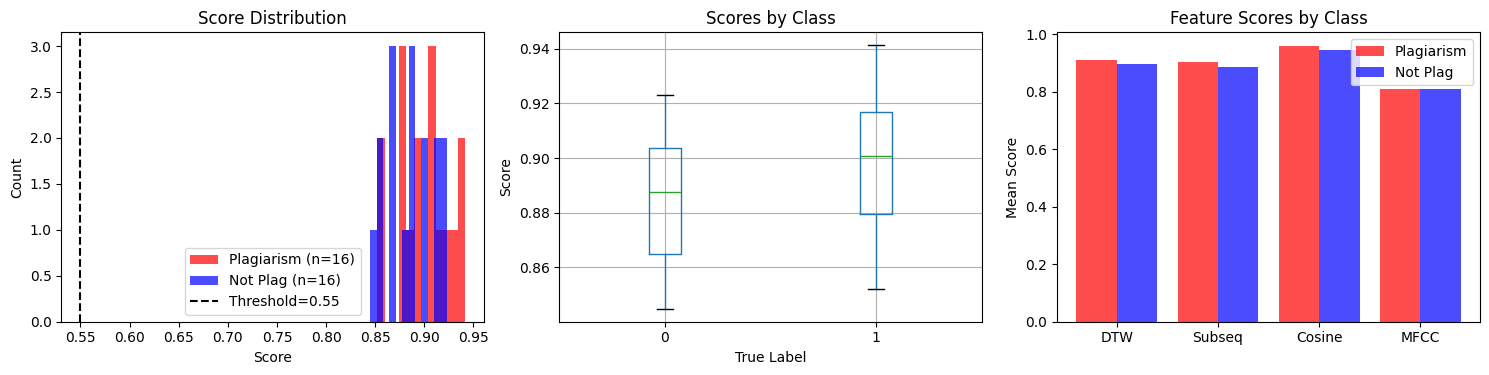

In [15]:
# Score distribution
valid = results_df[results_df['status'] == 'OK']

if len(valid) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram
    plag = valid[valid['true'] == 1]['score']
    not_plag = valid[valid['true'] == 0]['score']
    
    axes[0].hist(plag, bins=12, alpha=0.7, label=f'Plagiarism (n={len(plag)})', color='red')
    axes[0].hist(not_plag, bins=12, alpha=0.7, label=f'Not Plag (n={len(not_plag)})', color='blue')
    axes[0].axvline(x=config.threshold, color='black', linestyle='--', label=f'Threshold={config.threshold}')
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Score Distribution')
    axes[0].legend()
    
    # Boxplot
    valid.boxplot(column='score', by='true', ax=axes[1])
    axes[1].set_xlabel('True Label')
    axes[1].set_ylabel('Score')
    axes[1].set_title('Scores by Class')
    plt.suptitle('')
    
    # Feature importance
    if 'dtw' in valid.columns:
        means_plag = [valid[valid['true']==1]['dtw'].mean(), 
                      valid[valid['true']==1]['subseq'].mean(),
                      valid[valid['true']==1]['cosine'].mean(),
                      valid[valid['true']==1]['mfcc'].mean()]
        means_not = [valid[valid['true']==0]['dtw'].mean(), 
                     valid[valid['true']==0]['subseq'].mean(),
                     valid[valid['true']==0]['cosine'].mean(),
                     valid[valid['true']==0]['mfcc'].mean()]
        
        x = np.arange(4)
        axes[2].bar(x - 0.2, means_plag, 0.4, label='Plagiarism', color='red', alpha=0.7)
        axes[2].bar(x + 0.2, means_not, 0.4, label='Not Plag', color='blue', alpha=0.7)
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(['DTW', 'Subseq', 'Cosine', 'MFCC'])
        axes[2].set_ylabel('Mean Score')
        axes[2].set_title('Feature Scores by Class')
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()

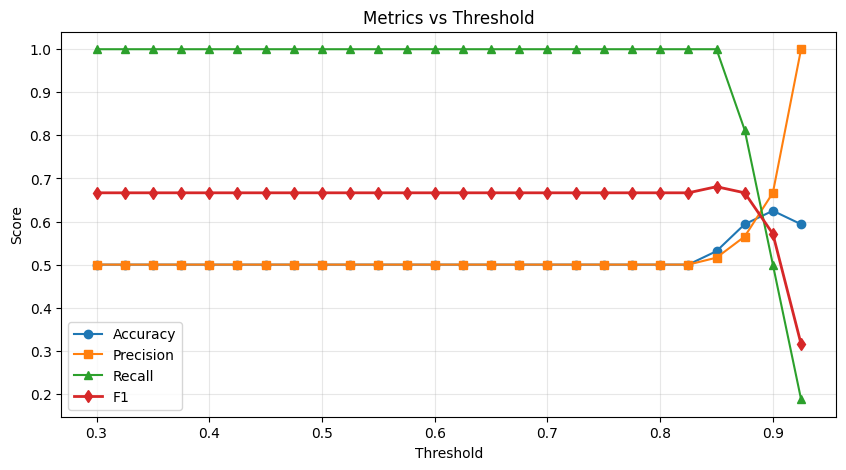


🏆 Best threshold: 0.850
   Accuracy: 0.531
   F1: 0.681


In [16]:
# Find optimal threshold
valid = results_df[results_df['status'] == 'OK']

if len(valid) > 0:
    thresholds = np.arange(0.3, 0.95, 0.025)
    metrics = []
    
    for thresh in thresholds:
        y_pred = (valid['score'] > thresh).astype(int)
        y_true = valid['true'].values
        
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        tn = ((y_true == 0) & (y_pred == 0)).sum()
        
        acc = (tp + tn) / (tp + tn + fp + fn)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        
        metrics.append({'threshold': thresh, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})
    
    metrics_df = pd.DataFrame(metrics)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(metrics_df['threshold'], metrics_df['accuracy'], 'o-', label='Accuracy')
    plt.plot(metrics_df['threshold'], metrics_df['precision'], 's-', label='Precision')
    plt.plot(metrics_df['threshold'], metrics_df['recall'], '^-', label='Recall')
    plt.plot(metrics_df['threshold'], metrics_df['f1'], 'd-', label='F1', linewidth=2)
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Metrics vs Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Best
    best_idx = metrics_df['f1'].idxmax()
    best = metrics_df.iloc[best_idx]
    print(f"\n🏆 Best threshold: {best['threshold']:.3f}")
    print(f"   Accuracy: {best['accuracy']:.3f}")
    print(f"   F1: {best['f1']:.3f}")

## 📊 Visualization of Comparison

In [17]:
def visualize_comparison(path1, path2, cfg, title="Comparison"):
    """Visualize comparison between two tracks"""
    feat1 = extract_features(path1, cfg)
    feat2 = extract_features(path2, cfg)
    
    result = compare_tracks(path1, path2, cfg)
    
    hpcp2_aligned = apply_oti(feat2['hpcp'], result.oti)
    sim_matrix = np.dot(feat1['hpcp'].T, hpcp2_aligned)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    
    # HPCP 1
    im1 = axes[0, 0].imshow(feat1['hpcp'], aspect='auto', origin='lower', cmap='magma')
    axes[0, 0].set_title('Query - HPCP')
    axes[0, 0].set_ylabel('Pitch Class')
    plt.colorbar(im1, ax=axes[0, 0])
    
    # HPCP 2
    im2 = axes[0, 1].imshow(hpcp2_aligned, aspect='auto', origin='lower', cmap='magma')
    axes[0, 1].set_title(f'Reference - HPCP (OTI={result.oti})')
    plt.colorbar(im2, ax=axes[0, 1])
    
    # Similarity
    im3 = axes[0, 2].imshow(sim_matrix, aspect='auto', origin='lower', cmap='viridis', vmin=0, vmax=1)
    axes[0, 2].set_title('Similarity Matrix')
    plt.colorbar(im3, ax=axes[0, 2])
    
    # Global profiles
    gc1 = np.mean(feat1['hpcp'], axis=1)
    gc2 = np.mean(hpcp2_aligned, axis=1)
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    x = np.arange(12)
    axes[1, 0].bar(x - 0.2, gc1, 0.4, label='Query', alpha=0.7)
    axes[1, 0].bar(x + 0.2, gc2, 0.4, label='Reference', alpha=0.7)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(notes, fontsize=8)
    axes[1, 0].set_title('Global Pitch Profiles')
    axes[1, 0].legend()
    
    # Scores
    scores = [result.dtw_sim, result.subseq_sim, result.cosine_sim, result.mfcc_sim]
    labels = ['DTW', 'Subseq', 'Cosine', 'MFCC']
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
    axes[1, 1].bar(labels, scores, color=colors)
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].axhline(y=cfg.threshold, color='black', linestyle='--')
    axes[1, 1].set_title('Score Breakdown')
    for i, v in enumerate(scores):
        axes[1, 1].text(i, v + 0.02, f'{v:.2f}', ha='center')
    
    # Result
    axes[1, 2].axis('off')
    status = "🚨 PLAGIARISM" if result.is_plagiarism else "✅ NOT PLAGIARISM"
    color = '#ffcccc' if result.is_plagiarism else '#ccffcc'
    
    text = f"""{status}\n\nCombined: {result.combined_score:.3f}\nThreshold: {cfg.threshold}"""
    axes[1, 2].text(0.5, 0.5, text, fontsize=14, ha='center', va='center',
                    transform=axes[1, 2].transAxes,
                    bbox=dict(boxstyle='round', facecolor=color))
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return result

Original: Queen - Under Pressure _Official Video_
Comparison: Vanilla Ice - Ice Ice Baby _Official Music Video_


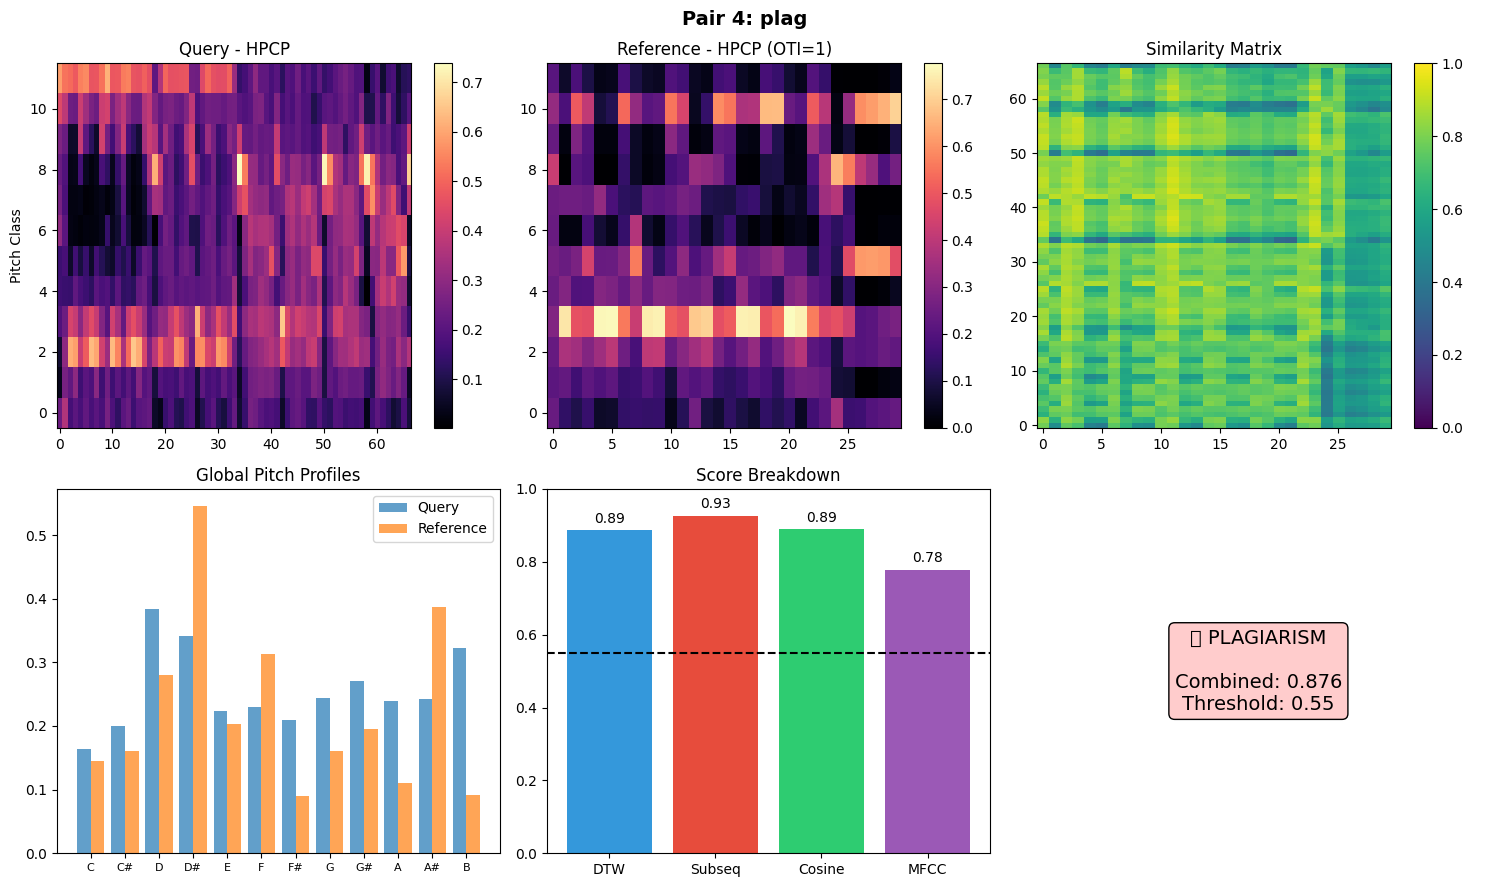

In [18]:
# Visualize specific pair
idx = 4  # Change this
row = df.iloc[idx]

ori_path = find_file(ORIGINAL_FOLDER, row['ori_title'])
comp_path = find_file(COMPARISON_FOLDER, row['comp_title'])

if ori_path and comp_path:
    print(f"Original: {row['ori_title'][:50]}")
    print(f"Comparison: {row['comp_title'][:50]}")
    visualize_comparison(str(comp_path), str(ori_path), config, f"Pair {idx}: {row['relation']}")
else:
    print("Files not found!")

## 💾 Save Results

In [ ]:
results_df.to_csv('results_optimized.csv', index=False)
print("✅ Results saved to results_optimized.csv")

## 💡 Tips for Improvement

1. **Tune threshold** based on the optimal threshold analysis
2. **Adjust weights** - maybe DTW is more important for your data
3. **Try without beat_sync** - might work better for some genres
4. **Add more features** - tonnetz, spectral contrast
5. **Ensemble** with MelodySim for best results